# **Distances Inter-Amino Acid**

## 📦 **Package Import**

In [1]:
# python
import pandas as pd
from IPython.display import display, Markdown
import sys
import os
from pathlib import Path

# algorithms4pepprotgraphs framework
sys.path.append('/home/jovyan/work/algorithms4pepprotgraphs')
from algorithms4pepprotgraphs.module.notebook import NotebookApp
from algorithms4pepprotgraphs.util.plotting import boxplot, histogram

# init framework backend
app = NotebookApp('.env.jupyter.StarPep')
paths = app.paths()

[2025-03-24 20:57:14,851] WARNING [data_validator.py:87] Sequences with non-natural amino acids were excluded. See: /home/jovyan/work/output/Test/Test2/Log/Sequences_with_non_natural_amino_acids.csv
[2025-03-24 20:57:24,290] INFO [notebook.py:51] Setting:
dataset_path: /home/jovyan/work/algorithms4pepprotgraphs/dataset/StarPep/StarPep.csv
pdb_path: /home/jovyan/work/algorithms4pepprotgraphs/dataset/StarPep/ESMFold_pdbs
notebook_output_path: /home/jovyan/work/output/Test/Test2
sequence_analysis_path: /home/jovyan/work/algorithms4pepprotgraphs/output/Test/2025-03-22T09.44.18-Sequence_Analyzer
graph_analysis_path: /home/jovyan/work/algorithms4pepprotgraphs/output/Test/2025-03-22T08.31.06-Graph_Analyzer


## 📊 **Data Analysis**

### **Statistics of Inter-Amino Acid Distances**

In [2]:
statistics = pd.read_csv(app.sequence_analysis['sequence_inter_amino_acid_distances_summary'])
statistics

,distance_function,count,min,mean,std,p25,p50,p75,max,skewness,kurtosis
0,euclidean,10013748,7.147880e-01,18.690692,11.801076,10.216160,16.477010,24.468511,194.841435,1.675293,9.318064
1,canberra,10013748,1.856425e-02,1.122874,0.605605,0.646259,1.061091,1.519128,3.000000,0.537500,2.796436
2,lance_williams,10013748,8.416540e-03,0.351029,0.205545,0.189433,0.317743,0.479542,1.000000,0.713842,3.007299
3,clark,10013748,1.332421e-02,0.731063,0.365580,0.436134,0.713267,1.009975,1.732051,0.254391,2.330074
4,soergel,10013748,1.669259e-02,0.487141,0.216747,0.318527,0.482253,0.648230,1.000000,0.126205,2.233165
5,bhattacharyya,10013748,9.129817e-02,2.714696,1.540128,1.541174,2.473060,3.627379,17.437551,0.912557,4.097661
6,angular_separation,10013748,5.067779e-09,0.139269,0.169544,0.019871,0.073317,0.194482,1.000000,1.920571,6.918774


### **Analysis of the Distribution of Inter-Amino Acid Distances (*per Distance Function*)**

#### **Euclidean, Bhattacharyya** (*$0 ≤ d_{s,t} ≤ ∞$*) 

<br>**Euclidean, Bhattacharyya** (*$0 ≤ d_{s,t} ≤ ∞$*)<br>

<br>Statistics (*Euclidean, Bhattacharyya*)

,distance_function,count,min,mean,std,p25,p50,p75,max,skewness,kurtosis
0,euclidean,10013748,0.714788,18.690692,11.801076,10.216160,16.47701,24.468511,194.841435,1.675293,9.318064
1,bhattacharyya,10013748,0.091298,2.714696,1.540128,1.541174,2.47306,3.627379,17.437551,0.912557,4.097661


<br>Inter Amino Acid Distances (*Euclidean, Bhattacharyya*)

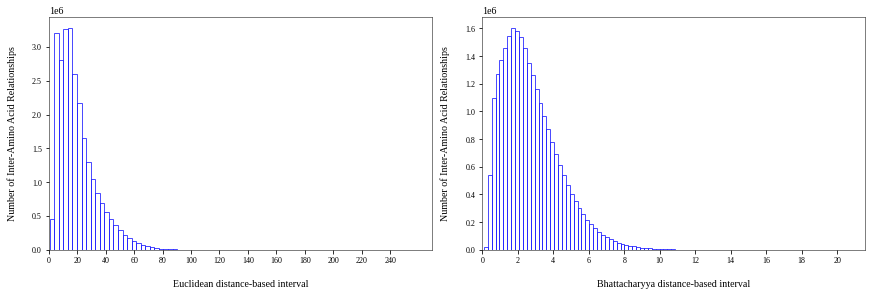

<br>Inter Amino Acid Distances (*Euclidean*)

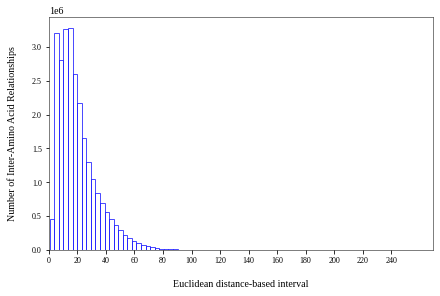

<br>Inter Amino Acid Distances (*Bhattacharyya*)

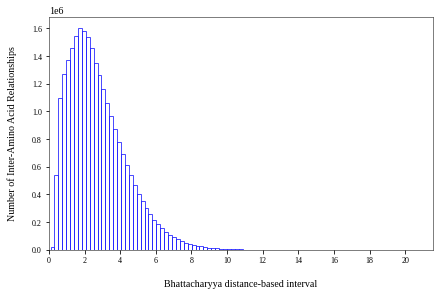

<br>Inter Amino Acid Distances (*Euclidean, Bhattacharyya*)

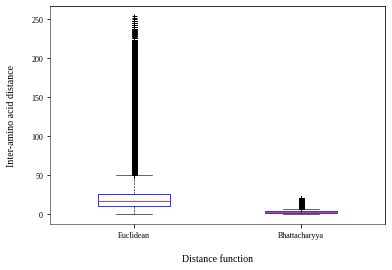

<br>Sequence with Largest Euclidean Distance: *RRLRPRRPRLPRPRPRPRPRPRSLPLPRPKPRPIPRPLPLPRPRPKPIPRPLPLPRPRPRRIPRPLPLPRPRPRPIPRPLPLPQPQPSPIPRPL*

Inter Amino Acid Distances (*Euclidean, Bhattacharyya*)

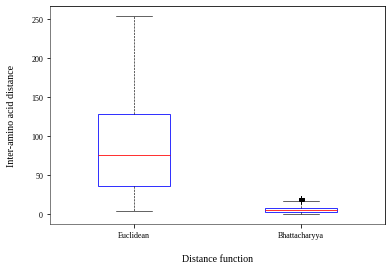

<br>Sequence with Largest Angular Separation Distance: *MWHLKLFAVLMICLLLLAQVDGSPIPQQSSAKRRPRRMTPFWRAVSLRPIGASCRDDSECITRLCRKRRCSLSVAQE*

Inter Amino Acid Distances (*Euclidean, Bhattacharyya*)

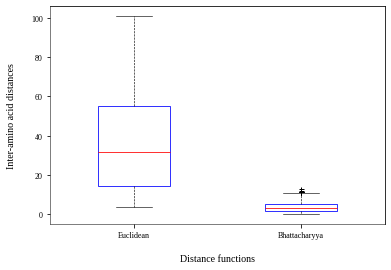

In [3]:
# distance functions 
distance_functions = ['euclidean', 'bhattacharyya']

# section name
display(Markdown("<br>**Euclidean, Bhattacharyya** (*$0 ≤ d_{s,t} ≤ ∞$*)<br>"))

# statistics
display(Markdown("<br>Statistics (*Euclidean, Bhattacharyya*)"))
display(statistics[statistics['distance_function'].isin(distance_functions)].reset_index(drop=True))

# histogram
distances = app.get_distance_values(distance_functions)

y_label = 'Number of Inter-Amino Acid Relationships'
x_labels = ['Euclidean distance-based interval', 'Bhattacharyya distance-based interval']
bin_width = [3.2, 0.22]
x_axis_step = [20, 2]

display(Markdown("<br>Inter Amino Acid Distances (*Euclidean, Bhattacharyya*)"))
output = paths['distances_inter_amino_acid_path'].joinpath("Inter Amino Acid Distances (eu_ba) -histogram ")
plt = histogram(distances, x_labels, y_label, bin_width=bin_width, x_axis_step=x_axis_step, output=output)
plt.show()

display(Markdown("<br>Inter Amino Acid Distances (*Euclidean*)"))
output = paths['distances_inter_amino_acid_path'].joinpath("Inter Amino Acid Distances (eu) -histogram")
plt = histogram(distances['euclidean'], x_labels[0], y_label, bin_width=bin_width[0], x_axis_step=x_axis_step[0], output=output)
plt.show()

display(Markdown("<br>Inter Amino Acid Distances (*Bhattacharyya*)"))
output = paths['distances_inter_amino_acid_path'].joinpath("Inter Amino Acid Distances (ba) -histogram")
plt = histogram(distances['bhattacharyya'], x_labels[1], y_label, bin_width=bin_width[1], x_axis_step=x_axis_step[1], output=output)
plt.show()
del distances, plt

# boxplot
distances = app.get_distance_values_and_pivot(distance_functions)
display(Markdown("<br>Inter Amino Acid Distances (*Euclidean, Bhattacharyya*)"))
x_axis = 'distance_function'
y_axis = 'value'
x_ticks = ['Euclidean', 'Bhattacharyya']
x_label = 'Distance function'
y_label = 'Inter-amino acid distance'
output = paths['distances_inter_amino_acid_path'].joinpath("Inter Amino Acid Distances (eu_ba) -boxplot")
y_lim=(-1, 240)
plt = boxplot(distances, x_axis, y_axis, x_label, y_label, x_ticks, y_lim=None, output=output, categories=distance_functions)
plt.show()
del distances, plt

# Sequence with Largest Euclidean Distance Value
result = app.get_sequences_with_largest_distance(distance_function='euclidean')
sequence = result['sequence'].item()
distances = app.get_distance_values_and_pivot(distance_functions, sequence)

display(Markdown(f"<br>Sequence with Largest Euclidean Distance: *{sequence}*"))
display(Markdown("Inter Amino Acid Distances (*Euclidean, Bhattacharyya*)"))

x_axis = 'distance_function'
y_axis = 'value'
x_ticks = ['Euclidean', 'Bhattacharyya']
x_label = 'Distance function'
y_label = 'Inter-amino acid distance'
output = paths['distances_inter_amino_acid_path'].joinpath("Inter Amino Acid Distances (eu_ba) -boxplot - (with_largest_eu_value)")
y_lim=(-1, 240)
plt = boxplot(distances, x_axis, y_axis, x_label, y_label, x_ticks, y_lim=None, output=output, categories=distance_functions)
plt.show()
del distances, plt

# Sequence with Largest Angular Separation Distance Value
result = app.get_sequences_with_largest_distance(distance_function='angular_separation')
sequence = result['sequence'].item()
distances = app.get_distance_values_and_pivot(distance_functions, sequence)

display(Markdown(f"<br>Sequence with Largest Angular Separation Distance: *{sequence}*"))
display(Markdown("Inter Amino Acid Distances (*Euclidean, Bhattacharyya*)"))

x_axis = 'distance_function'
y_axis = 'value'
x_ticks = ['Euclidean', 'Bhattacharyya']
x_label = 'Distance functions'
y_label = 'Inter-amino acid distances'
output = paths['distances_inter_amino_acid_path'].joinpath("Inter Amino Acid Distances (eu_ba) -boxplot - (with_largest_as_value)")
y_lim=(-1, 240)

plt = boxplot(distances, x_axis, y_axis, x_label, y_label, x_ticks, y_lim=None, output=output, categories=distance_functions)
plt.show()

del distances, plt

**Canberra, Clark** (*$0 ≤ d_{s,t} ≤ p : p = 3$*)

<br>**Canberra, Clark** (*$0 ≤ d_{s,t} ≤ p : p = 3$*)<br>

<br>Statistics (*Canberra, Clark*)

,distance_function,count,min,mean,std,p25,p50,p75,max,skewness,kurtosis
0,canberra,10013748,0.018564,1.122874,0.605605,0.646259,1.061091,1.519128,3.000000,0.537500,2.796436
1,clark,10013748,0.013324,0.731063,0.365580,0.436134,0.713267,1.009975,1.732051,0.254391,2.330074


<br>Inter Amino Acid Distances (*Canberra, Clark*)

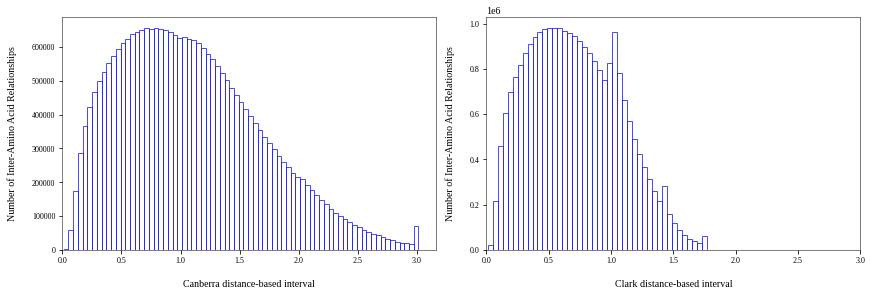

<br>Inter Amino Acid Distances (*Canberra*)

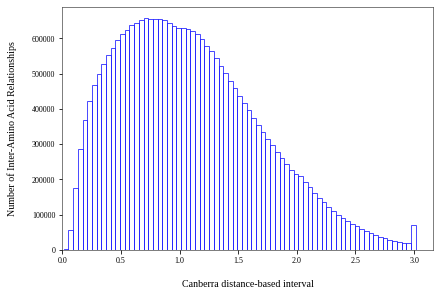

<br>Inter Amino Acid Distances (*Clark*)

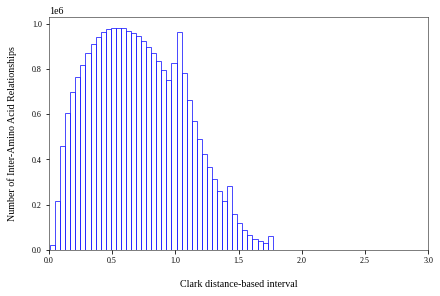

<br>Inter Amino Acid Distances (*Canberra, Clark*)

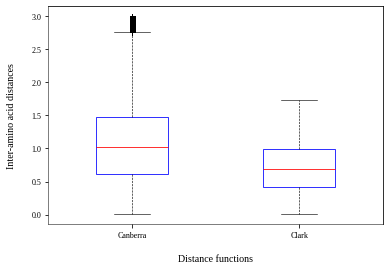

In [4]:
# distance functions
distance_functions = ['canberra', 'clark']

# section name
display(Markdown("<br>**Canberra, Clark** (*$0 ≤ d_{s,t} ≤ p : p = 3$*)<br>"))

# statistics
display(Markdown("<br>Statistics (*Canberra, Clark*)"))
display(statistics[statistics['distance_function'].isin(distance_functions)].reset_index(drop=True))

# histograms
distances = app.get_distance_values(distance_functions)

y_label = 'Number of Inter-Amino Acid Relationships'
x_labels = ['Canberra distance-based interval', 'Clark distance-based interval']
bin_width = 0.04
x_axis_step = 0.5

display(Markdown("<br>Inter Amino Acid Distances (*Canberra, Clark*)"))
output = paths['distances_inter_amino_acid_path'].joinpath("Inter Amino Acid Distances (ca_cl) -histogram")
plt = histogram(distances, x_labels, y_label, bin_width=bin_width, x_axis_step=x_axis_step, x_axis_max=3, output=output)
plt.show()

display(Markdown("<br>Inter Amino Acid Distances (*Canberra*)"))
output = paths['distances_inter_amino_acid_path'].joinpath("Inter Amino Acid Distances (ca) -histogram")
plt = histogram(distances['canberra'], x_labels[0], y_label, bin_width=bin_width, x_axis_step=x_axis_step, x_axis_max=3, output=output)
plt.show()

display(Markdown("<br>Inter Amino Acid Distances (*Clark*)"))
output = paths['distances_inter_amino_acid_path'].joinpath("Inter Amino Acid Distances (cl) -histogram")
plt = histogram(distances['clark'], x_labels[1], y_label, bin_width=bin_width, x_axis_step=x_axis_step, x_axis_max=3, output=output)
plt.show()

del distances, plt

# boxplot
distances = app.get_distance_values_and_pivot(distance_functions)

display(Markdown("<br>Inter Amino Acid Distances (*Canberra, Clark*)"))
x_axis = 'distance_function'
y_axis = 'value'
x_ticks = ['Canberra', 'Clark']
x_label = 'Distance functions'
y_label = 'Inter-amino acid distances'
output = paths['distances_inter_amino_acid_path'].joinpath("Inter Amino Acid Distances (ca_cl) -boxplot")
y_lim=(-1, 240)
plt = boxplot(distances, x_axis, y_axis, x_label, y_label, x_ticks, y_lim=None, output=output, categories=distance_functions)
plt.show()

del distances, plt

**Angular Separation, Lance Williams, Soergel** (*$0 ≤ d_{s,t} ≤ 1$*)

<br>**Angular Separation, Lance Williams, Soergel** (*$0 ≤ d_{s,t} ≤ 1$*)<br>

<br>Statistics (*Angular Separation, Lance Williams, Soergel*)

,distance_function,count,min,mean,std,p25,p50,p75,max,skewness,kurtosis
0,lance_williams,10013748,8.416540e-03,0.351029,0.205545,0.189433,0.317743,0.479542,1.0,0.713842,3.007299
1,soergel,10013748,1.669259e-02,0.487141,0.216747,0.318527,0.482253,0.648230,1.0,0.126205,2.233165
2,angular_separation,10013748,5.067779e-09,0.139269,0.169544,0.019871,0.073317,0.194482,1.0,1.920571,6.918774


<br>Inter Amino Acid Distances (*Angular Separation, Lance Williams, Soergel*)

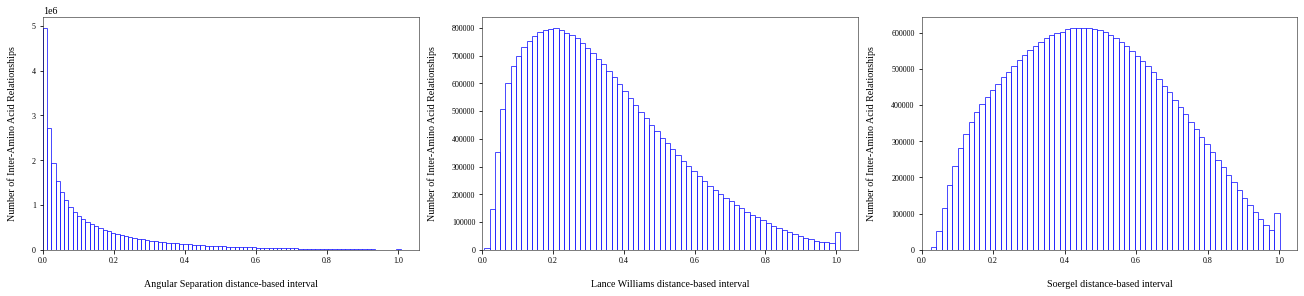

<br>Inter Amino Acid Distances (*Angular Separation)

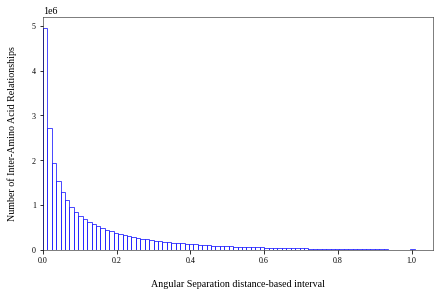

<br>Inter Amino Acid Distances (*Lance Williams*)

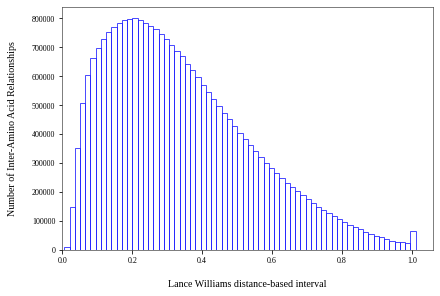

<br>Inter Amino Acid Distances (*Soergel*)

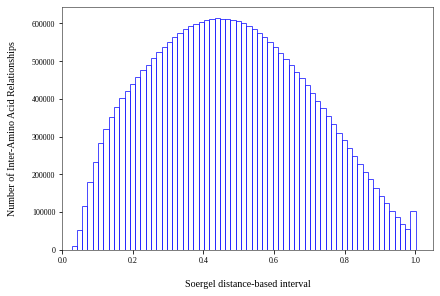

<br>Inter Amino Acid Distances (*Angular Separation, Lance Williams, Soergel*)

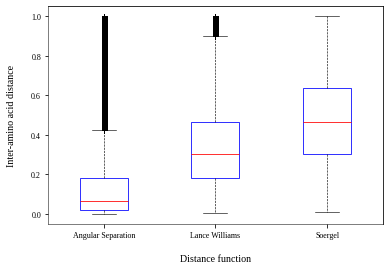

<br>Sequence: *ALWKNMLKGIGKLAGKAALGAVKKLVGAES*

Inter Amino Acid Distances (*Angular Separation, Lance Williams, Soergel)

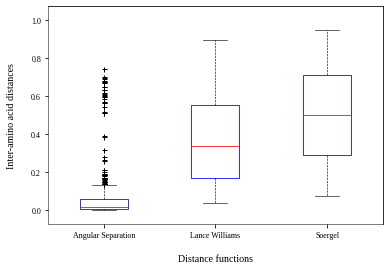

In [5]:
# distance_functions
distance_functions = ['angular_separation', 'lance_williams', 'soergel']

# section name
display(Markdown("<br>**Angular Separation, Lance Williams, Soergel** (*$0 ≤ d_{s,t} ≤ 1$*)<br>"))

# statistics
display(Markdown("<br>Statistics (*Angular Separation, Lance Williams, Soergel*)"))
display(statistics[statistics['distance_function'].isin(distance_functions)].reset_index(drop=True))

# histograms
distances = app.get_distance_values(distance_functions)

y_label = 'Number of Inter-Amino Acid Relationships'
x_labels = ['Angular Separation distance-based interval', 'Lance Williams distance-based interval', 'Soergel distance-based interval']
bin_width = [0.012, 0.015, 0.015]
x_axis_step = 0.2

display(Markdown("<br>Inter Amino Acid Distances (*Angular Separation, Lance Williams, Soergel*)"))
output = paths['distances_inter_amino_acid_path'].joinpath("Inter Amino Acid Distances (as_lw_so) -histogram")
plt = histogram(distances, x_labels, y_label, bin_width=bin_width, x_axis_step=x_axis_step, x_axis_max=1, output=output)
plt.show()

display(Markdown("<br>Inter Amino Acid Distances (*Angular Separation)"))
output = paths['distances_inter_amino_acid_path'].joinpath("Inter Amino Acid Distances (as) -histogram")
plt = histogram(distances['angular_separation'], x_labels[0], y_label, bin_width[0], x_axis_step, x_axis_max=1, output=output)
plt.show()

display(Markdown("<br>Inter Amino Acid Distances (*Lance Williams*)"))
output = paths['distances_inter_amino_acid_path'].joinpath("Inter Amino Acid Distances (lw) -histogram")
plt = histogram(distances['lance_williams'], x_labels[1], y_label, bin_width[1], x_axis_step, x_axis_max=1, output=output)
plt.show()

display(Markdown("<br>Inter Amino Acid Distances (*Soergel*)"))
output = paths['distances_inter_amino_acid_path'].joinpath("Inter Amino Acid Distances (so) -histogram")
plt = histogram(distances['soergel'], x_labels[2], y_label, bin_width[2], x_axis_step, x_axis_max=1, output=output)
plt.show()

del distances, plt

# boxplot
distances = app.get_distance_values_and_pivot(distance_functions)

display(Markdown("<br>Inter Amino Acid Distances (*Angular Separation, Lance Williams, Soergel*)"))
x_axis = 'distance_function'
y_axis = 'value'
x_ticks =['Angular Separation', 'Lance Williams', 'Soergel']
x_label = 'Distance function'
y_label = 'Inter-amino acid distance'
output = paths['distances_inter_amino_acid_path'].joinpath("Inter Amino Acid Distances (as_lw_so) -boxplot")
y_lim=(-1, 240)
plt = boxplot(distances, x_axis, y_axis, x_label, y_label, x_ticks, y_lim=None, output=output, categories=distance_functions)
plt.show()

del distances, plt

# Inter-amino acid Distance of the sequence 'ALWKNMLKGIGKLAGKAALGAVKKLVGAES'
distance_functions = ['angular_separation', 'lance_williams', 'soergel']
sequence = 'ALWKNMLKGIGKLAGKAALGAVKKLVGAES'
distances = app.get_distance_values_and_pivot(distance_functions, sequence)

display(Markdown("<br>Sequence: *ALWKNMLKGIGKLAGKAALGAVKKLVGAES*"))
display(Markdown("Inter Amino Acid Distances (*Angular Separation, Lance Williams, Soergel)"))
x_axis = 'distance_function'
y_axis = 'value'
x_ticks =['Angular Separation', 'Lance Williams', 'Soergel']
x_label = 'Distance functions'
y_label = 'Inter-amino acid distances'
output = paths['distances_inter_amino_acid_path'].joinpath("Inter Amino Acid Distances (as_lw_so) -boxplot (sequence)")
y_lim=(-0.07, 1.07)

plt = boxplot(distances, x_axis, y_axis, x_label, y_label, x_ticks, y_lim=y_lim, output=output, categories=distance_functions)
plt.show()

del distances, plt

<br>Inter Amino Acid Distances (*Angular Separation, Lance Williams, Soergel*)

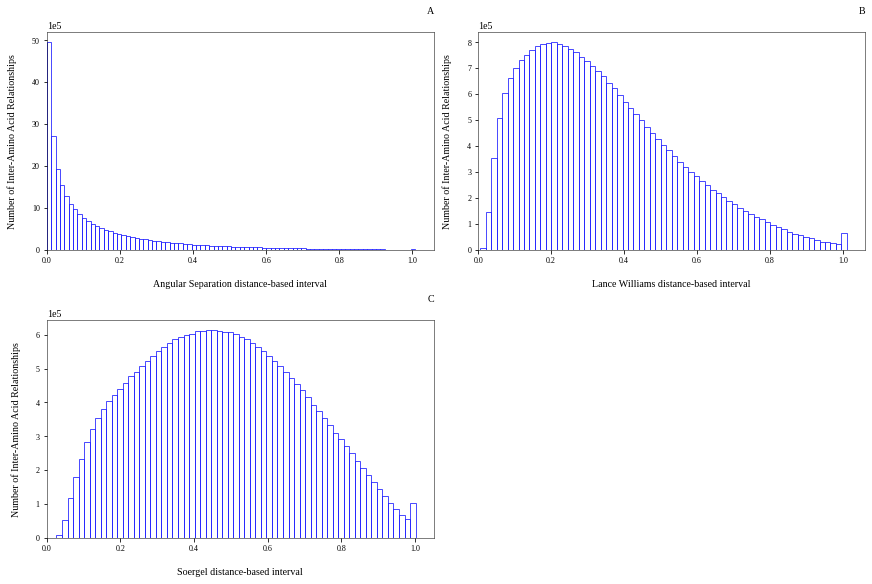

In [6]:
# distance_functions
distance_functions = ['angular_separation', 'lance_williams', 'soergel']

# histograms
distances = app.get_distance_values(distance_functions)

display(Markdown("<br>Inter Amino Acid Distances (*Angular Separation, Lance Williams, Soergel*)"))
y_label = 'Number of Inter-Amino Acid Relationships'
x_labels = ['Angular Separation distance-based interval', 'Lance Williams distance-based interval', 'Soergel distance-based interval']
bin_width = [0.012, 0.015, 0.015]
x_axis_step = 0.2
output = paths['distances_inter_amino_acid_path'].joinpath("Inter Amino Acid Distances (as_lw_so) -histogram_v)")
titles=['A', 'B', 'C']
plt = histogram(distances, x_labels, y_label, bin_width=bin_width, x_axis_step=x_axis_step, x_axis_max=1, output=output, titles=titles, n_cols=2, y_sci_limits=5, title_pad=18)
plt.show()

del distances, plt